In [102]:
pip install pandas_ods_reader

Note: you may need to restart the kernel to use updated packages.


In [103]:
from pandas_ods_reader import read_ods
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize


In [132]:
files = ["C:/vpv_res/air2.ods","C:/vpv_res/air3.ods","C:/vpv_res/air4.ods","C:/vpv_res/air5.ods","C:/vpv_res/air6.ods"]
A = []
W = []

In [133]:
def test_func(x, a, b, c, d):
    return a * np.sin(b * x + c) + d


In [134]:
for u in range(len(files)):
    base_path = files[u]
    sheet_index = 1
    df = read_ods(base_path , sheet_index)
    type(df.iloc[0]['t'])
    d_array = df.to_numpy()
    d_array_t = d_array[0:150, 0]
    d_array_x = d_array[0:150, 1]
    a = (max(d_array_x) - min(d_array_x))/2
    c = 0
    d = a+min(d_array_x)
    pic1 =list(d_array_x).index(max(d_array_x))
    pic2 =0
    i = pic1+1
    pred = max(d_array_x)
    for y in range(i,1000):
        if (d_array_x[y]<pred):      
            y = y+1
            pred = d_array_x[y-1]
        else:
            break
    pred = d_array_x[y-1]
    for z in range(y,1000):
        if (d_array_x[z]>pred):      
            z = z+1
            pred = d_array_x[z-1]
        else:
            break
    pred = d_array_x[z-1]
    pic2 = list(d_array_x).index(pred)
    b = 2*3.14/(d_array_t[pic2]- d_array_t[pic1])
    p0 = [a,b,c,d]
    params, params_covariance = optimize.curve_fit(test_func, d_array_t, d_array_x,
                                           p0)
    A.append(a)
    W.append(b)
    a=0
    b = 0
    d = 0
    y = 0
    z = 0
    i = 0 
    pred = 0
    plt.figure(figsize=(6, 4))
    plt.scatter(d_array_t, d_array_x, label='Data')
    plt.plot(d_array_t, test_func(d_array_t, params[0], params[1], params[2], params[3]),
             label='Fitted function')

    plt.legend(loc='best')
    plt.show()


IndexError: index 150 is out of bounds for axis 0 with size 150

In [130]:
print(A)
print(W)

[]
[]


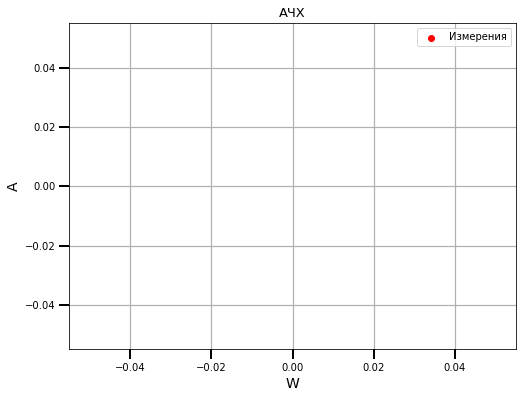

In [131]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("АЧХ", fontsize=13)
ax.set_xlabel("W", fontsize=14)
ax.set_ylabel("А", fontsize=14)
ax.grid(which="major", linewidth=1.2)
ax.grid(which="minor", linestyle="--", color="gray", linewidth=0.5)
ax.scatter(W,A, c="red",label = "Измерения" )
ax.legend()
ax.tick_params(which='major', length=10, width=2)
ax.tick_params(which='minor', length=5, width=1)
plt.show()

In [23]:
base_path = files[0]
sheet_index = 1
df = read_ods(base_path , sheet_index)

In [24]:
df

,t,y
0,0.000000,0.063249
1,0.033333,0.063785
2,0.066667,0.064594
3,0.100000,0.065570
4,0.133333,0.066529
...,...,...
358,11.933333,0.065025
359,11.966667,0.066254
360,12.000000,0.067697
361,12.033333,0.068951


In [5]:
type(df.iloc[0]['t'])

numpy.float64

In [6]:
import numpy as np

# Seed the random number generator for reproducibility

# And plot it
import matplotlib.pyplot as plt

In [8]:
d_array = df.to_numpy()

In [9]:
d_array.shape

(363, 2)

In [17]:
d_array_t = d_array[0:150, 0]
d_array_x = d_array[0:150, 1]

In [18]:
from scipy import optimize

def test_func(x, a, b, c, d):
    return a * np.sin(b * x + c) + d

params, params_covariance = optimize.curve_fit(test_func, d_array_t, d_array_x,
                                               p0=[0.006, 10, 0, 0.06])

print(params)

[ 3.20384389e-03  1.02567324e+01 -1.43723666e+00  6.60138310e-02]


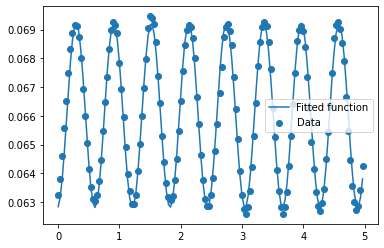

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(d_array_t, d_array_x, label='Data')
plt.plot(d_array_t, test_func(d_array_t, params[0], params[1], params[2], params[3]),
         label='Fitted function')

plt.legend(loc='best')

plt.show()

In [13]:
params  

array([ 3.15804248e-03,  1.00461181e+01, -1.21888510e+00,  6.61031646e-02])